# 12-2 LLM을 미세 조정해 작업에 특화시키기

본 노트북은 12-2절 본문 예제 [코드 12-8]~[코드 12-16]을 모아 위에서 아래로
실행한다. 사전 학습된 한국어 BART(KoBART)를 네이버 뉴스 요약 데이터셋으로
미세 조정해 뉴스 요약기(모델 16)를 만든다.

**이 장의 코드 컨벤션 알림** - 12장은 허깅페이스 라이브러리를 중심 주제로
다루므로, `MODEL_NAME` 등 상수 표기는 공통 컨벤션을 따르지만 `model`,
`tokenizer`, `trainer` 같은 객체명은 HF 통용 표기를 그대로 사용한다.
입력·정답 변수도 §3.5(C)에 따라 HF 표준(`input_ids`, `attention_mask`,
`labels`)을 그대로 쓴다.

다루는 내용
- [코드 12-8] 허깅페이스 허브 등록 데이터셋 불러오기
- [코드 12-9] 전처리 콜백 함수 정의와 map() 적용
- [코드 12-10] 사전 학습된 KoBART 모델 불러오기
- [코드 12-11] 모델 질문 함수 query_lm()
- [코드 12-12] 배치 병합 객체와 학습 설정 객체
- [코드 12-13] Seq2SeqTrainer 학습 엔진 생성 및 실행
- 미세 조정 전과 후의 비교 ([표 12-6] 대응)

> 사용 모델: gogamza/kobart-base-v2 (MIT 라이선스).
> 사용 데이터셋: daekeun-ml/naver-news-summarization-ko (Apache-2.0 라이선스).


In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q datasets transformers
# !pip install accelerate>=1.1.0

In [2]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

device = common.get_device()

CUDA를 사용합니다.


In [ ]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED)
device = common.get_device()

# # 참고 - 라이브러리 import 와 시드 고정
# import random
# import time
# import warnings

# import numpy as np
# import torch
# from datasets import load_dataset
# from transformers import (
#     AutoModelForSeq2SeqLM, AutoTokenizer,
#     DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments,
# )

# warnings.filterwarnings('ignore')

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)


## [코드 12-8] 허깅페이스 허브 등록 데이터셋 불러오기

`datasets` 라이브러리의 `load_dataset()`으로 데이터셋을 불러오면 train /
validation / test 키를 가진 `DatasetDict`를 반환한다. 빠른 학습을 위해
`select()`로 훈련 500, 검증 100 샘플만 골라 쓴다.


In [ ]:
###############################################################################
# 코드 12-8 - 허깅페이스 허브 등록 데이터셋 불러오기
###############################################################################
dataset = load_dataset('daekeun-ml/naver-news-summarization-ko')
print(dataset)

TRAIN_SIZE, VALID_SIZE = 500, 100
# 허깅페이스 Dataset의 select() 메서드 - 인덱스 기반 샘플링
train_dataset = dataset['train'].select(range(TRAIN_SIZE))
valid_dataset = dataset['validation'].select(range(VALID_SIZE))

print(f'\n훈련 샘플 수: {len(train_dataset):,}')
print(f'검증 샘플 수: {len(valid_dataset):,}')
print(f'첫 샘플 컬럼: {list(train_dataset[0].keys())}')


DatasetDict({
    train: Dataset({
        features: ['date', 'category', 'press', 'title', 'document', 'link', 'summary'],
        num_rows: 22194
    })
    validation: Dataset({
        features: ['date', 'category', 'press', 'title', 'document', 'link', 'summary'],
        num_rows: 2466
    })
    test: Dataset({
        features: ['date', 'category', 'press', 'title', 'document', 'link', 'summary'],
        num_rows: 2740
    })
})

훈련 샘플 수: 500
검증 샘플 수: 100
첫 샘플 컬럼: ['date', 'category', 'press', 'title', 'document', 'link', 'summary']


## [코드 12-9] 전처리 콜백 함수 정의와 map() 적용

허깅페이스 `Dataset`은 `map()` 메서드로 콜백 함수를 전체에 적용해 일괄 변환한다.
뉴스 원문은 `input_ids`/`attention_mask`로, 요약문은 `labels`로 인코딩한다.
데이터셋 단계에서는 `padding=False`로 두고, 패딩은 뒤의 배치 병합 객체가 맡는다.


In [5]:
# 코드 12-9 - 전처리 콜백 함수 정의와 map() 적용
MODEL_NAME = 'gogamza/kobart-base-v2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 128

# 전처리 콜백 함수: examples는 샘플이 아닌 샘플 묶음(map(batched=True))
def preprocess(examples):
    # 뉴스 원문 인코딩: input_ids, attention_mask 컬럼이 생긴다.
    model_inputs = tokenizer(
        examples['document'], max_length=MAX_INPUT_LENGTH,
        truncation=True, padding=False,
    )
    # 요약문 인코딩: input_ids만 labels 컬럼으로 사용한다.
    labels = tokenizer(
        examples['summary'], max_length=MAX_TARGET_LENGTH,
        truncation=True, padding=False,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs


# map() 메서드 + 전처리 콜백 함수: 데이터셋 전체에 전처리 적용
tokenized_train = train_dataset.map(            # 훈련 데이터셋
    preprocess, batched=True, remove_columns=train_dataset.column_names,
)
tokenized_valid = valid_dataset.map(            # 검증 데이터셋
    preprocess, batched=True, remove_columns=valid_dataset.column_names,
)

print(f'전처리된 컬럼: {tokenized_train.column_names}')
print(f'첫 샘플 input_ids 길이: {len(tokenized_train[0]["input_ids"])}')
print(f'첫 샘플 labels 길이   : {len(tokenized_train[0]["labels"])}')


전처리된 컬럼: ['input_ids', 'attention_mask', 'labels']
첫 샘플 input_ids 길이: 315
첫 샘플 labels 길이   : 65


## [코드 12-10] 사전 학습된 KoBART 모델 불러오기

인코더와 디코더를 모두 갖춘 KoBART는 `AutoModelForSeq2SeqLM`으로 불러온다.
정확한 Auto 클래스를 써야 `generate()` 같은 작업별 메서드를 사용할 수 있다.


In [6]:
# 코드 12-10 - 사전 학습된 KoBART 모델 불러오기
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

print(f'모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}')
print(f'토크나이저 어휘 크기: {tokenizer.vocab_size:,}')


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

모델 파라미터 수: 123,859,968
토크나이저 어휘 크기: 30,000


## [코드 12-11] 모델 질문 함수 query_lm()

미세 조정 전후 결과를 같은 방식으로 비교하기 위한 질문 함수다. 생성 방식은 빔
너비 4의 빔 서치(`do_sample=False`, `num_beams=4`)이며, 반복을 막기 위해
`no_repeat_ngram_size`와 `repetition_penalty`를 함께 지정한다.


In [7]:
# 코드 12-11 - 모델 질문 함수 query_lm()
def query_lm(text, model, tokenizer,
             max_input=MAX_INPUT_LENGTH, max_output=MAX_TARGET_LENGTH):
    inputs = tokenizer(
        text, return_tensors='pt', max_length=max_input, truncation=True,
    ).to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_output,
            do_sample=False,            # 탐욕 디코딩(기본값)
            num_beams=4,                # 빔 너비 4의 빔 서치
            early_stopping=True,        # 완성 빔이 num_beams개가 되면 탐색 종료
            no_repeat_ngram_size=3,     # 3-gram 반복 금지
            repetition_penalty=1.2,     # 반복 토큰 생성 페널티
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


# 미세 조정하지 않은 모델의 결과 (이후 비교를 위해 별도 객체로 보관)
model_before = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
model_before.eval()
print(query_lm(dataset['test'][0]['document'], model_before, tokenizer))


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

단에에 관한 것이다. 해당 단말기 특허에 관한이다. 해당 단말 단말 단말기 신규 특허는 자동차 주행 중 운전자의 졸음운전을 방지하는 상태 검출 기술에 관한하다. 해당 단말기는 가시광선 및 근적외선 광원을 조사하는 광원 모듈 운전자의 얼굴 영상을 촬영하는 가시광 선 및 근 적외선 카메라 차량 실내의 이산화탄소 농도를 농도를 측정하는 이산화 탄소 센서로 구성됐다.이산화탄소 센도로 구성됐는데다. 구성 구성 구성지 모순순순스 센도를 향 향 향을 기준 기준 기준 산 산 산을 들 들 들 기준 기준


## [코드 12-12] 배치 병합 객체와 학습 설정 객체

`Seq2SeqTrainer`는 배치 병합 객체(`DataCollatorForSeq2Seq`)와 학습 설정 객체
(`Seq2SeqTrainingArguments`)를 사용한다. 배치 병합 객체는 배치 단계에서 패딩을
더하고, 학습 설정 객체는 하이퍼파라미터를 포함한 학습 환경을 전달한다.


In [8]:
#!pip install -U accelerate>=1.1.0

In [9]:
# 코드 12-12 - 배치 병합 객체와 학습 설정 객체
# 배치 단계에서 패딩을 추가하는 배치 병합 객체
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

training_args = Seq2SeqTrainingArguments(
    output_dir='../../checkpoint/kobart-news', num_train_epochs=2,
    per_device_train_batch_size=4, per_device_eval_batch_size=4,
    warmup_steps=50,                 # 학습률을 점진적으로 올리는 미니배치 수
    weight_decay=0.01,               # 과적합 방지를 위한 가중치 감쇠 계수
    logging_steps=50,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True,
    predict_with_generate=True,      # 검증 단계에서 generate()로 출력 시퀀스 생성
    fp16=False,                      # CPU/MPS 환경 호환을 위해 비활성.
    # GPU(CUDA) 환경에서는 True -> 학습 속도와 메모리 모두 유리
    report_to='none',                # 외부 로깅 서비스 미사용
)


## [코드 12-13] Seq2SeqTrainer 학습 엔진 생성 및 실행

두 객체와 데이터셋을 묶어 `Seq2SeqTrainer`를 만든 뒤 `train()`을 호출하면 미세
조정이 시작된다. 예제는 2 에포크만 학습한다. 학습이 끝난 모델은 `trainer.model`에
담긴다.


In [10]:
# 코드 12-13 - Seq2SeqTrainer 학습 엔진 생성 및 실행
trainer = Seq2SeqTrainer(
    model=model, args=training_args, train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    processing_class=tokenizer,      # 최근 버전에서 tokenizer -> processing_class
    data_collator=data_collator,
)

# Trainer가 학습 로그(네이티브)를 직접 출력한다. 직접 에포크 print는 만들지 않고,
# 반환된 metrics의 train_runtime으로 전체 학습 시간만 사람이 읽기 좋게 출력한다(§7.7).
result = trainer.train()             # 미세 조정 학습 실행
print(f'전체 학습 시간: {result.metrics["train_runtime"]:.1f}초')

Epoch,Training Loss,Validation Loss
1,0.907465,0.718295
2,0.530356,0.695196


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


전체 학습 시간: 38.1초


## 참고 - 학습 곡선 (log_history 기반)

`Trainer`는 학습 로그를 `trainer.state.log_history`에 (스텝 단위) 누적한다.
여기서 훈련 손실(`loss`)과 검증 손실(`eval_loss`)을 뽑아 스텝별 학습 곡선을
그린다(§7.7). 표는 Trainer가 이미 출력하므로 곡선만 추가한다.

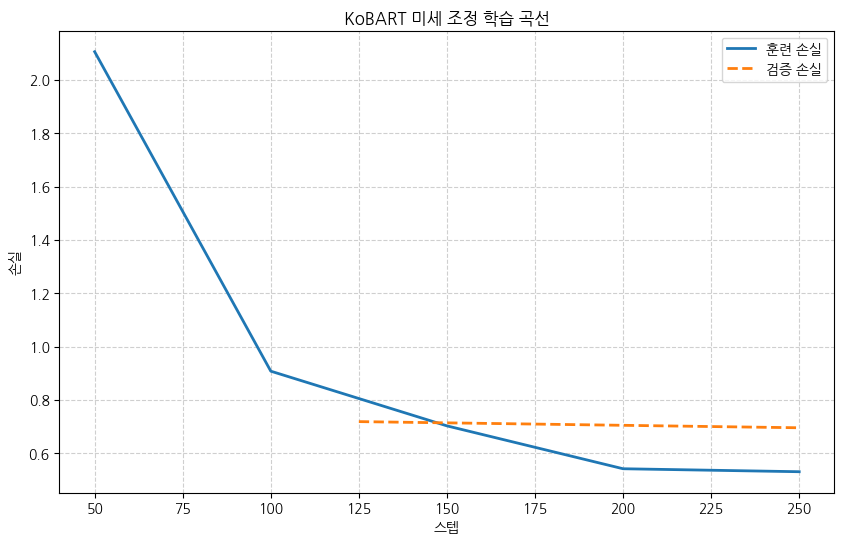

In [11]:
# 참고 - log_history에서 손실을 뽑아 학습 곡선을 그린다 (§7.7)
train_curve = [(rec['step'], rec['loss'])
               for rec in trainer.state.log_history if 'loss' in rec]
eval_curve = [(rec['step'], rec['eval_loss'])
              for rec in trainer.state.log_history if 'eval_loss' in rec]

viz.plot_histories(
    {'훈련 손실': train_curve, '검증 손실': eval_curve},
    title='KoBART 미세 조정 학습 곡선', x_label='스텝', y_label='손실',
)

## 미세 조정 전과 후의 비교 ([표 12-6] 대응)

학습 전후의 모델로 같은 뉴스 기사를 요약해 비교한다. 표는 요약문 앞부분 50자만
발췌하며, 괄호 안 숫자는 입력과 출력 전체의 글자 수다.


In [12]:
# 참고 - 미세 조정 전후의 요약 결과 비교 ([표 12-6] 대응)
model_after = trainer.model
model_after.eval()

for i in range(3):
    sample = dataset['test'][i]
    before = query_lm(sample['document'], model_before, tokenizer)
    after = query_lm(sample['document'], model_after, tokenizer)
    print(f'\n[뉴스 원문 {i + 1}] (입력 {len(sample["document"])}자)')
    print(f'  학습 전 출력(50자): {before[:50]}... ({len(before)}자)')
    print(f'  학습 후 출력(50자): {after[:50]}... ({len(after)}자)')



[뉴스 원문 1] (입력 570자)
  학습 전 출력(50자): 단에에 관한 것이다. 해당 단말기 특허에 관한이다. 해당 단말 단말 단말기 신규 특허는 자... (274자)
  학습 후 출력(50자): 아이엘사이언스의 자회사 아이트로닉스는 차량용 복합기능형 졸음 방지 단말기 특허를 출원했다고... (307자)

[뉴스 원문 2] (입력 1728자)
  학습 전 출력(50자): 다.다.이다.이다.다.이다.다.다.한다.다.다.다. 것이다.다.다.했다.다.다. 한다.다.... (270자)
  학습 후 출력(50자): 한국형 우주발사체 누리호 가 지난 6월 21일 전남 고흥 나로우주센터 발사대에서 날아올라 ... (294자)

[뉴스 원문 3] (입력 1361자)
  학습 전 출력(50자): 던 증시 3대지수 모두 하락 대형주 중심의 미국 스탠더드앤드푸어스 S P 500 지수가 올... (305자)
  학습 후 출력(50자): 뉴욕증거래소 NYSE 에서 다우존스 산업평균지수는 전장보다 253.88포인트 0.82% 하... (269자)


## [코드 12-16 대응] 분야 밖 일반 텍스트 입력 결과

마지막은 뉴스가 아닌 일반 텍스트(된장찌개 레시피)를 입력한 결과다. 학습 전
모델은 토큰을 끝없이 이어 붙이지만, 학습 후 모델은 입력보다 짧게 줄여 낸다.


In [13]:
# 참고 - 분야 밖 일반 텍스트 입력 결과 ([표 12-6] 마지막 행 대응)
sample_text = (
    '이 자라야 한다는 것은 내가 아니라 장차 내 아내가 될 점순이의 키 말이다. '
    '내가 여기에 와서 돈 한푼 안 받고 일하기를 삼 년 하고 꼬박이 일곱 달 동안을 했다. '
    '그런데도 미처 못 자랐다니까 이 키는 언제야 자라는 겐지 짜장 영문 모른다. '
    '일을 좀더 잘해야 한다든지 혹은 밥을 (많이 먹는다고 노상 걱정이니까) 좀 덜 먹어야 '
    '한다든지 하면 나도 얼마든지 할 말이 많다. 하지만 점순이가 아직 어리니까 더 자라야 '
    '한다는 여기에는 어째 볼 수 없이 그만 벙벙하고 만다. 이래서 나는 애최 계약이 잘못된 '
    '걸 알았다. 이태면 이태, 삼 년이면 삼 년, 기한을 딱 작정하고 일을 했어야 원 할 것이다. '
    '덮어놓고 딸이 자라는 대로 성례를 시켜 주마, 했으니 누가 늘 지키고 섰는 것도 아니고 '
    '그 키가 언제 자라는지 알 수 있는가. 그리고 난 사람의 키가 무럭무럭 자라는 줄만 알았지 '
    '붙박이 키에 모로만 벌어지는 몸도 있는 것을 누가 알았으랴. 때가 되면 장인님이 어련하랴 '
    '싶어서 군소리 없이 꾸벅꾸벅 일만 해왔다.'    
)
before = query_lm(sample_text, model_before, tokenizer)
after = query_lm(sample_text, model_after, tokenizer)
print(f'입력 ({len(sample_text)}자): {sample_text[:50]}...')
print(f'학습 전 출력 ({len(before)}자): {before[:50]}...')
print(f'학습 후 출력 ({len(after)}자): {after[:50]}...')


입력 (506자): 이 자라야 한다는 것은 내가 아니라 장차 내 아내가 될 점순이의 키 말이다. 내가 여기에 ...
학습 전 출력 (281자): 이 자라야 한다는 것은 내가 아니라 장차 내 아내가 될 점순이의 키 말이다. 내가 여기에 ...
학습 후 출력 (264자): 점순이가 아직 어리니까 더 자라야 한다는 여기에는 어째 볼 수 없이 그만 벙벙하고 만다. ...


In [14]:
print(before)
print(after)

이 자라야 한다는 것은 내가 아니라 장차 내 아내가 될 점순이의 키 말이다. 내가 여기에 와서 돈 한푼 안 받고 일하기를 삼 년 하고 꼬박이 일곱 달 동안을 했다. 그런데도 미처 못 자랐다니까 이 키는 언제야 자라는 겐지 짜장 영문 모른다. 일을 좀더 잘해야 한다든지 혹은 밥을 (많이 먹는다고 노상 걱정이니까) 좀 덜 먹어야 한다든지 하면 나도 얼마든지 할 말이 많다. 하지만 점순이가 아직 어리니까 더 자라야다는 여기에는 어째 볼 수 없이 그만 벙벙하고 만다. 이래서 나는 애최 계약이 잘못된 걸 알
점순이가 아직 어리니까 더 자라야 한다는 여기에는 어째 볼 수 없이 그만 벙벙하고 만다. 나는 애최 계약이 잘못된 걸 알았다. 이태면 이태, 삼 년이면 삼 년, 기한을 딱 작정하고 일을 했어야 원 할 것이다. 덮어놓고 딸이 자라는 대로 성례를 시켜 주마, 했으니 누가 늘 지키고 섰는 것도 아니고 그 키가 언제 자라는지 알 수 있는가. 그리고 난 사람의 키가 무럭무럭 자라는 줄만 알았지 붙박이 키에 모로만 벌어지는 몸도 있는 것을 누가 알았으랴. 때가 되면 장인님이 어련
